# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Es la continuación de la Tarea 1, por lo que se utilizarán los mismos datos y se puede reutilizar cualquier parte del código de dicha tarea.

Puede copiar este notebook en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y las librerías Pandas y scikit-learn. Para esta tarea se recomienda consultar la sección [Extracting features from text files](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) de la documentación oficial de scikit-learn.

Recuerde que **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook.

In [1]:
from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Configuracion visual: Times New Roman + viridis, consistente con la Tarea 1.
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.titlesize": 14,
    "figure.dpi": 110,
})

RANDOM_STATE = 42

# Etiquetas cortas y paleta viridis fija por medio.
ORDER = ["Reuters", "NY Times", "CNBC"]
LABEL_TO_PUB = {"Reuters": "Reuters", "NY Times": "The New York Times", "CNBC": "CNBC"}
PUB_TO_LABEL = {v: k for k, v in LABEL_TO_PUB.items()}
_cmap = matplotlib.colormaps["viridis"]
PALETTE = dict(zip(ORDER, [_cmap(p) for p in (0.0, 0.45, 0.75)]))


def short(y):
    """Pasa los nombres completos de los medios a etiquetas cortas."""
    return pd.Series(y).map(PUB_TO_LABEL).values

/Users/nicole/.pyenv/versions/3.12.13/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Descarga del dataset
Se utilizan los mismos datos que en la Tarea 1. Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas.

In [2]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

# Parte 1: Dataset y representación numérica de texto

## 1. Preparación del dataset
Se utilizará un conjunto de datos reducido de los **tres medios de prensa con mayor cantidad de artículos**.
Se espera que utilice su propia versión de la función `clean_text()` de la Tarea 1.

Particione los datos para generar un conjunto de test del 30% del total, utilizando muestreo estratificado.

**Sugerencia**: utilice el parámetro `stratify` de la función `train_test_split` de scikit-learn y fije también el valor de `random_state` para obtener resultados reproducibles.

In [3]:
def clean_text(df, column_name):
    """Normaliza el texto de una columna del DataFrame.

    Elimina el dateline inicial (todo hasta el primer salto de linea), pasa a
    minusculas, unifica las variantes de apostrofo, elimina puntuacion y
    digitos (preservando apostrofes de las contracciones) y colapsa los
    espacios en blanco.
    """
    return (
        df[column_name]
        .fillna("")
        .astype(str)
        .str.replace(r"^[^\n]*\n", "", regex=True)
        .str.lower()
        .str.replace(r"[‘’`]", "'", regex=True)
        .str.replace(r"[^\w\s']", " ", regex=True)
        .str.replace(r"\d+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

In [4]:
# Tres medios con mayor cantidad de articulos.
top_3_publications = df["publication"].value_counts().head(3).index.tolist()
print("Top 3 medios:", top_3_publications)

df_top_3 = df[df["publication"].isin(top_3_publications)].copy()
df_top_3 = df_top_3[df_top_3["article"].notna()]

# Texto limpio sobre el cuerpo del articulo.
df_top_3["CleanText"] = clean_text(df_top_3, "article")
df_top_3["publication"].value_counts()

Top 3 medios: ['Reuters', 'The New York Times', 'CNBC']


publication
Reuters               9272
The New York Times    2810
CNBC                  2578
Name: count, dtype: int64

In [5]:
X = df_top_3["CleanText"]
y = df_top_3["publication"]

# Particion 70/30 con muestreo estratificado para preservar las proporciones.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 10262 | Test: 4398


## 2. Verificación del balance de clases
Genere una visualización que permita verificar que el balance de artículos de cada medio es similar en train y test.

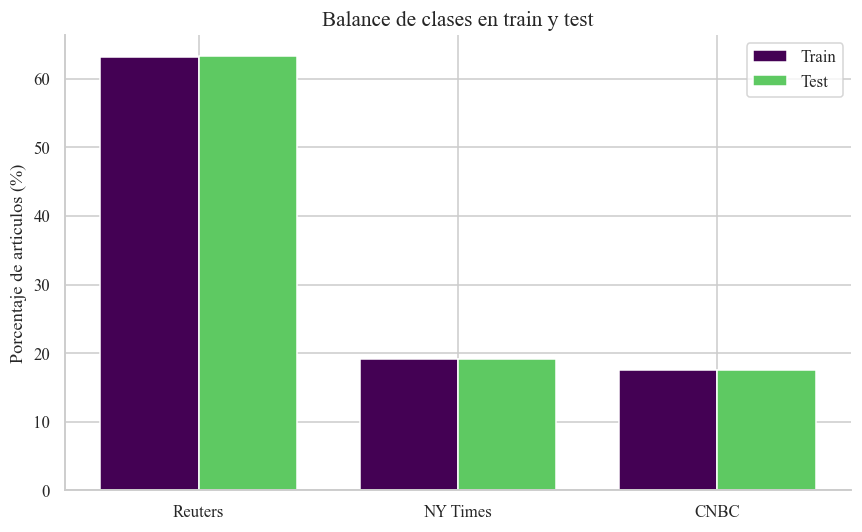

Reuters     63.24
NY Times    19.17
CNBC        17.59
Name: proportion, dtype: float64
Reuters     63.26
NY Times    19.17
CNBC        17.58
Name: proportion, dtype: float64


In [6]:
prop_train = pd.Series(short(y_train)).value_counts(normalize=True).reindex(ORDER)
prop_test = pd.Series(short(y_test)).value_counts(normalize=True).reindex(ORDER)

x = np.arange(len(ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, prop_train * 100, w, label="Train", color=_cmap(0.0), edgecolor="white")
ax.bar(x + w / 2, prop_test * 100, w, label="Test", color=_cmap(0.75), edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(ORDER)
ax.set_ylabel("Porcentaje de articulos (%)")
ax.set_title("Balance de clases en train y test")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

print((prop_train * 100).round(2))
print((prop_test * 100).round(2))

## 3. Representación Bag of Words
Transforme el texto del conjunto de entrenamiento a una representación numérica (features) de conteo de palabras (*bag of words*).
Explique brevemente cómo funciona esta técnica y muestre un ejemplo.
En particular, explique el tamaño de la matriz resultante y la razón por la que es una matriz *sparse*.

**Sugerencia**: puede ser útil imaginar qué sucedería con la memoria RAM requerida si no estuviéramos trabajando con un conjunto de datos reducido.

In [7]:
count_vec = CountVectorizer()
X_train_counts = count_vec.fit_transform(X_train)

n_docs, n_vocab = X_train_counts.shape
print(f"Matriz BoW: {X_train_counts.shape}  (documentos x vocabulario)")
print(f"Elementos no nulos: {X_train_counts.nnz:,}")
print(f"Sparsity: {100 * (1 - X_train_counts.nnz / (n_docs * n_vocab)):.2f}%")
print(f"Tamano si fuera densa (float64): {n_docs * n_vocab * 8 / 1e9:.2f} GB")

# Ejemplo: palabras con mayor conteo en el primer documento de entrenamiento.
vocab = np.array(count_vec.get_feature_names_out())
fila = X_train_counts[0]
top = fila.indices[np.argsort(fila.data)[::-1][:8]]
pd.DataFrame({"palabra": vocab[top], "conteo": fila.toarray().ravel()[top]})

Matriz BoW: (10262, 83566)  (documentos x vocabulario)
Elementos no nulos: 2,148,522
Sparsity: 99.75%
Tamano si fuera densa (float64): 6.86 GB


,palabra,conteo
0,ep,6
1,energy,6
2,production,6
3,corp,4
4,hurricane,3
5,company,3
6,impact,3
7,operational,2


## 4. Representación TF-IDF
Explique brevemente qué es un **n-grama**.
Obtenga la representación numérica *Term Frequency - Inverse Document Frequency* (TF-IDF).
Explique brevemente en qué consiste esta transformación adicional.

In [8]:
tfidf_vec = TfidfVectorizer()
X_train_tfidf = tfidf_vec.fit_transform(X_train)
print(f"Matriz TF-IDF: {X_train_tfidf.shape} | no nulos: {X_train_tfidf.nnz:,}")

Matriz TF-IDF: (10262, 83566) | no nulos: 2,148,522


## 5. Visualización PCA sobre TF-IDF
Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de TF-IDF.
Analice los resultados y compare qué sucede si utiliza:
- a) el filtrado de `stop_words` para idioma inglés;
- b) el parámetro `use_idf=True`;
- c) `ngram_range=(1,2)`.

Opcionalmente, también puede analizar qué sucede si no elimina los signos de puntuación.

¿Se pueden separar los medios de prensa utilizando sólo 2 componentes principales?
Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (por ejemplo, hasta 10 componentes).

Discuta además si la separación observada puede deberse a diferencias de estilo editorial, a diferencias temáticas o a pistas explícitas del medio que no hayan sido removidas en la limpieza.

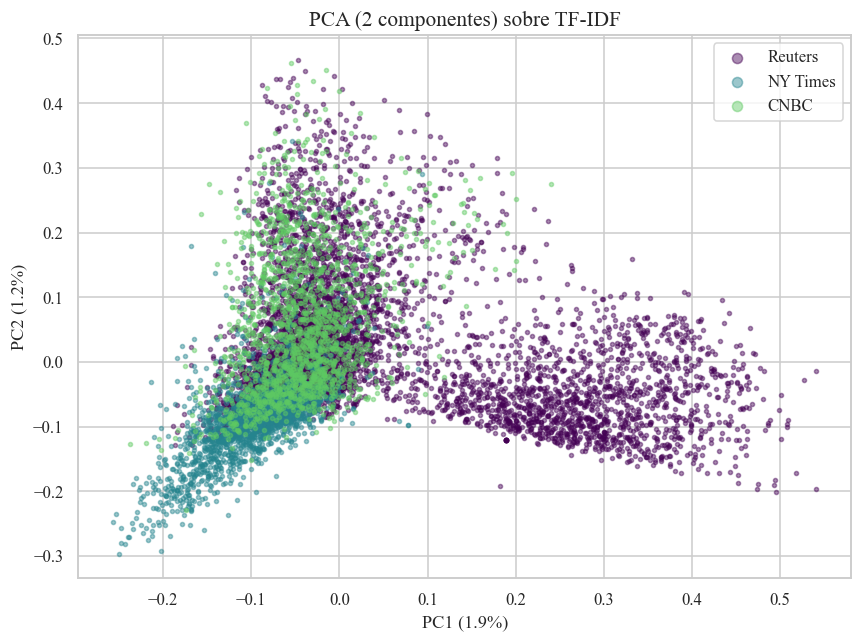

In [9]:
# PCA requiere matriz densa; se acota el vocabulario a las 5000 palabras mas
# frecuentes para poder densificar sin agotar la memoria.
PCA_MAX_FEATURES = 5000

vec = TfidfVectorizer(stop_words="english", max_features=PCA_MAX_FEATURES)
Xv = vec.fit_transform(X_train).toarray()
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xv)
ev = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xv).explained_variance_ratio_ * 100

y_train_lbl = short(y_train)
fig, ax = plt.subplots(figsize=(8, 6))
for lbl in ORDER:
    m = y_train_lbl == lbl
    ax.scatter(coords[m, 0], coords[m, 1], s=7, alpha=0.45, color=PALETTE[lbl], label=lbl)
ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)")
ax.set_title("PCA (2 componentes) sobre TF-IDF")
ax.legend(markerscale=2.5); plt.tight_layout(); plt.show()

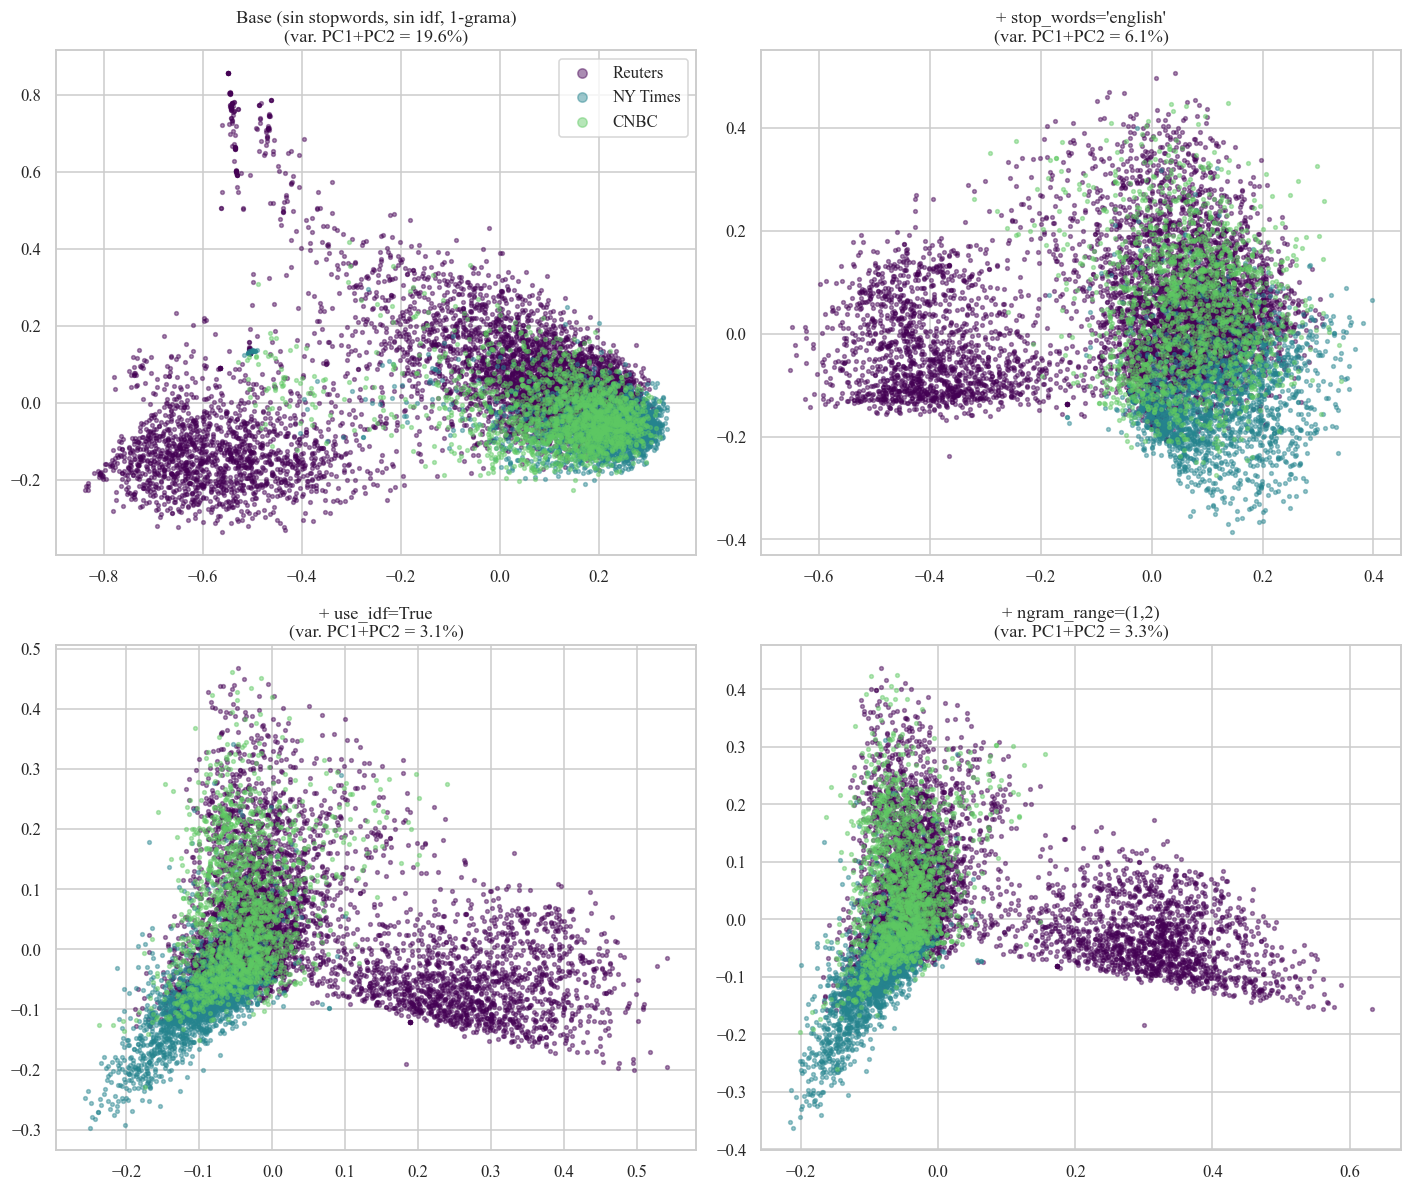

In [10]:
configs = [
    ("Base (sin stopwords, sin idf, 1-grama)",
     dict(stop_words=None, use_idf=False, ngram_range=(1, 1))),
    ("+ stop_words='english'",
     dict(stop_words="english", use_idf=False, ngram_range=(1, 1))),
    ("+ use_idf=True",
     dict(stop_words="english", use_idf=True, ngram_range=(1, 1))),
    ("+ ngram_range=(1,2)",
     dict(stop_words="english", use_idf=True, ngram_range=(1, 2))),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11)); axes = axes.flatten()
for ax, (titulo, params) in zip(axes, configs):
    vec = TfidfVectorizer(max_features=PCA_MAX_FEATURES, **params)
    Xv = vec.fit_transform(X_train).toarray()
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(Xv)
    for lbl in ORDER:
        m = y_train_lbl == lbl
        ax.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.45, color=PALETTE[lbl], label=lbl)
    ev = pca.explained_variance_ratio_ * 100
    ax.set_title(f"{titulo}\n(var. PC1+PC2 = {ev.sum():.1f}%)", fontsize=12)
axes[0].legend(markerscale=2.5)
plt.tight_layout(); plt.show()

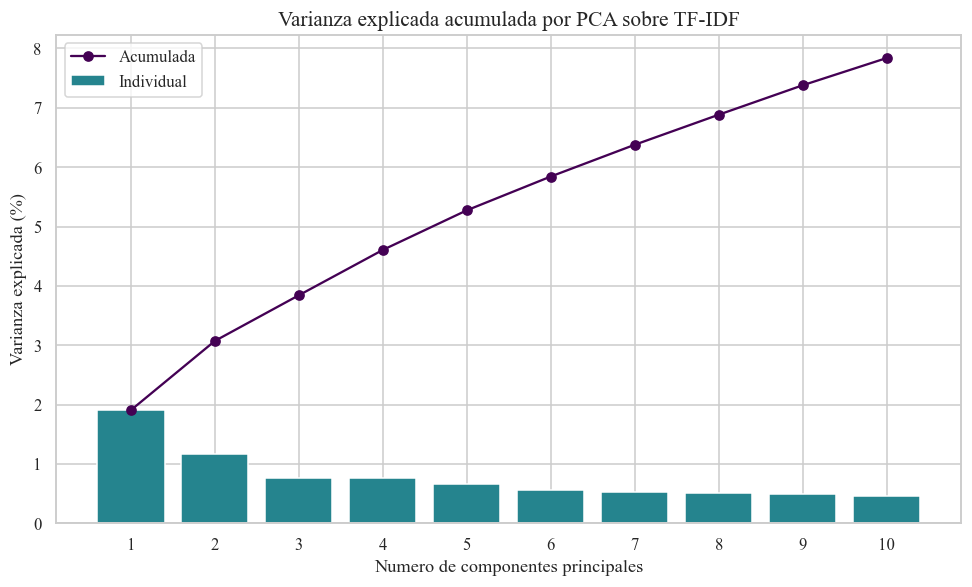

Varianza acumulada (%): [1.91 3.07 3.84 4.61 5.27 5.84 6.38 6.88 7.38 7.84]


In [11]:
vec = TfidfVectorizer(stop_words="english", max_features=PCA_MAX_FEATURES)
Xv = vec.fit_transform(X_train).toarray()
pca10 = PCA(n_components=10, random_state=RANDOM_STATE).fit(Xv)
evr = pca10.explained_variance_ratio_ * 100
cum = np.cumsum(evr)

comps = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(comps, evr, color=_cmap(0.45), edgecolor="white", label="Individual")
ax.plot(comps, cum, "-o", color=_cmap(0.0), label="Acumulada")
ax.set_xlabel("Numero de componentes principales")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza explicada acumulada por PCA sobre TF-IDF")
ax.set_xticks(comps); ax.legend(); plt.tight_layout(); plt.show()

print("Varianza acumulada (%):", cum.round(2))

# Parte 2: Entrenamiento y Evaluación de Modelos

## 1. Multinomial Naive Bayes
Entrene el modelo *Multinomial Naive Bayes* para clasificar los artículos según a qué medio de prensa pertenece el texto.
Utilice dicho modelo para clasificar los artículos del conjunto de test, y reporte el valor de *accuracy* y la **matriz de confusión**.
Reporte además el valor de *precision* y *recall* para cada medio.
Explique cómo se relacionan estos valores con la matriz anterior.

¿Qué problemas puede tener el hecho de mirar solamente el valor de *accuracy*?
Considere qué sucedería con esta métrica si el desbalance de datos fuera aún mayor entre medios.

**Sugerencia**: utilice el método `from_predictions` de `ConfusionMatrixDisplay` para realizar la matriz.

In [12]:
tfidf = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Accuracy: 0.7283

                    precision    recall  f1-score   support

              CNBC       1.00      0.02      0.04       773
           Reuters       0.70      1.00      0.82      2782
The New York Times       0.96      0.49      0.65       843

          accuracy                           0.73      4398
         macro avg       0.89      0.50      0.50      4398
      weighted avg       0.80      0.73      0.65      4398



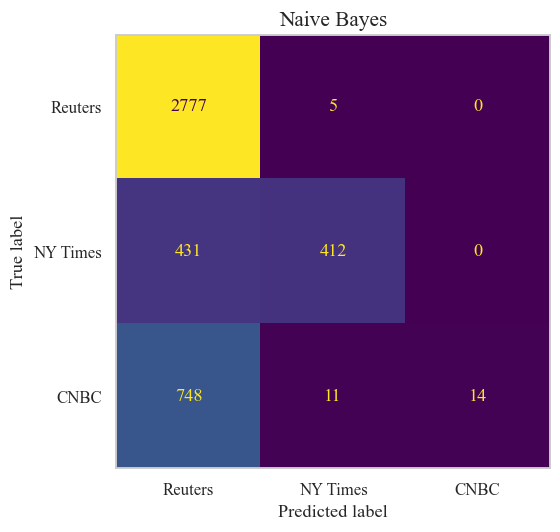

In [13]:
y_pred = nb.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=[LABEL_TO_PUB[l] for l in ORDER],
    display_labels=ORDER, cmap="viridis", colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Naive Bayes"); plt.tight_layout(); plt.show()

## 2. Validación cruzada y búsqueda de hiperparámetros
Explique cómo funciona la técnica de **validación cruzada** (*cross-validation*).
Implemente una búsqueda de hiperparámetros usando `GridSearchCV`.
Genere una visualización que permita comparar las métricas (por ejemplo, *accuracy*) de los distintos modelos entrenados, viendo el valor promedio y la variabilidad de las mismas en todos los *splits* (por ejemplo, en un gráfico de violín).

In [14]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", MultinomialNB()),
])
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__alpha": [0.01, 0.1, 1.0],
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
print("Mejor combinacion:", grid.best_params_)
print(f"Mejor accuracy CV: {grid.best_score_:.4f}")

Mejor combinacion: {'clf__alpha': 0.01, 'tfidf__ngram_range': (1, 2)}
Mejor accuracy CV: 0.8461


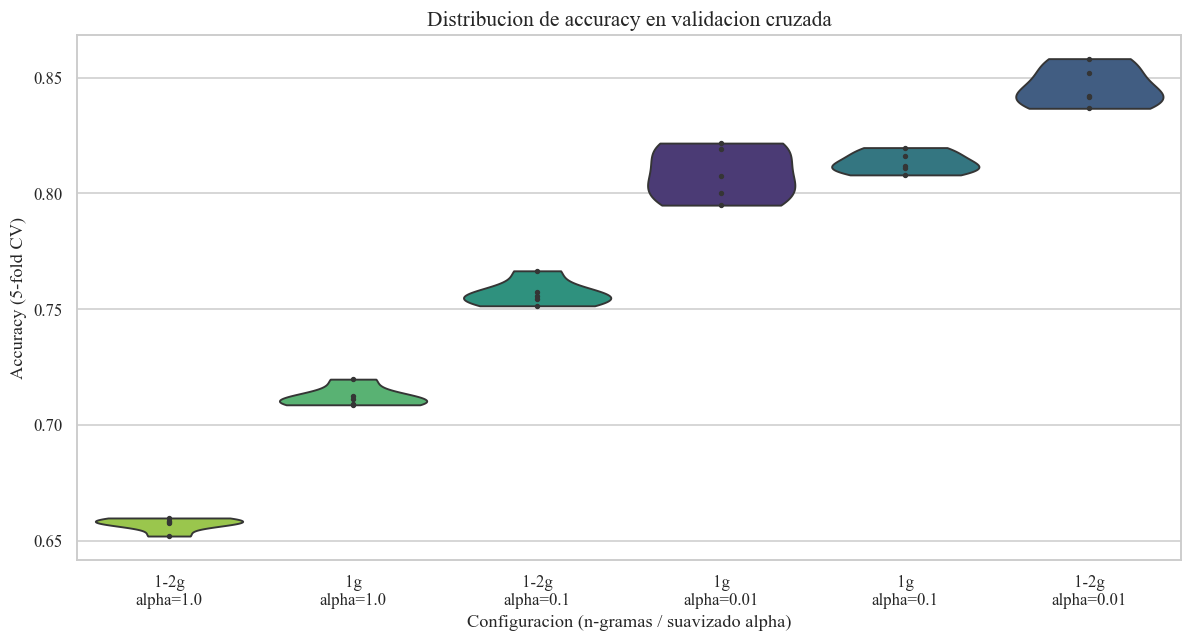

In [15]:
res = grid.cv_results_
rows = []
for i, params in enumerate(res["params"]):
    ng = "1-2g" if params["tfidf__ngram_range"] == (1, 2) else "1g"
    nombre = f"{ng}\nalpha={params['clf__alpha']}"
    for s in range(5):
        rows.append({"modelo": nombre, "accuracy": res[f"split{s}_test_score"][i]})
cv_df = pd.DataFrame(rows)
orden = cv_df.groupby("modelo")["accuracy"].mean().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(data=cv_df, x="modelo", y="accuracy", order=orden,
               hue="modelo", legend=False, palette="viridis", inner="point", cut=0, ax=ax)
ax.set_xlabel("Configuracion (n-gramas / suavizado alpha)")
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("Distribucion de accuracy en validacion cruzada")
plt.tight_layout(); plt.show()

## 3. Entrenamiento final con el mejor modelo
Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación).
Reporte el valor final de las métricas y la matriz de confusión.
Discuta las limitaciones de utilizar un modelo basado en *bag of words* o TF-IDF para el análisis de texto.

In [16]:
# Se re-entrena el mejor modelo sobre todo el conjunto de entrenamiento.
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Accuracy: 0.8561

                    precision    recall  f1-score   support

              CNBC       0.80      0.50      0.61       773
           Reuters       0.87      0.95      0.91      2782
The New York Times       0.83      0.89      0.86       843

          accuracy                           0.86      4398
         macro avg       0.83      0.78      0.79      4398
      weighted avg       0.85      0.86      0.85      4398



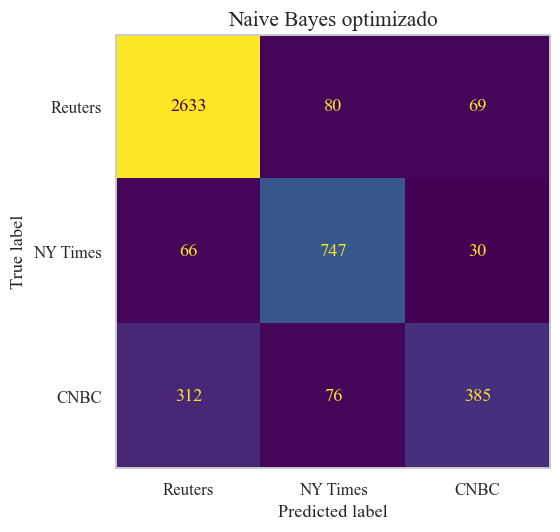

In [17]:
y_pred_best = best_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}\n")
print(classification_report(y_test, y_pred_best))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, labels=[LABEL_TO_PUB[l] for l in ORDER],
    display_labels=ORDER, cmap="viridis", colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Naive Bayes optimizado"); plt.tight_layout(); plt.show()

## 4. Modelo alternativo
Evalúe al menos un modelo más (dentro de scikit-learn) aparte de *Multinomial Naive Bayes* para clasificar el texto utilizando las mismas *features* de texto.
Explique brevemente cómo funciona y compare los resultados con el anterior.

Accuracy LogReg: 0.9009

                    precision    recall  f1-score   support

              CNBC       0.85      0.62      0.72       773
           Reuters       0.90      0.97      0.93      2782
The New York Times       0.96      0.92      0.94       843

          accuracy                           0.90      4398
         macro avg       0.90      0.84      0.86      4398
      weighted avg       0.90      0.90      0.90      4398



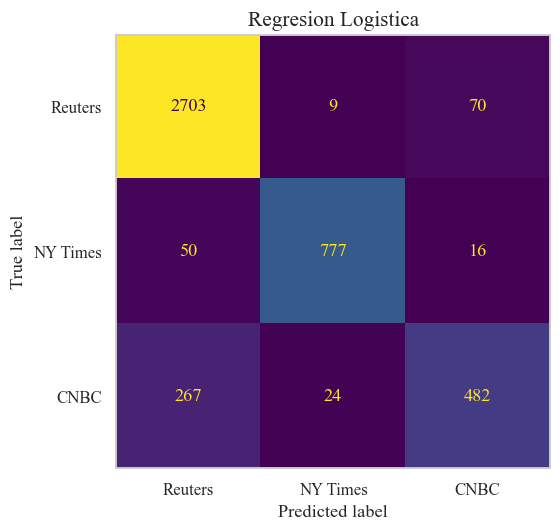

In [18]:
logreg = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, C=10)),
])
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print(f"Accuracy LogReg: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, labels=[LABEL_TO_PUB[l] for l in ORDER],
    display_labels=ORDER, cmap="viridis", colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Regresion Logistica"); plt.tight_layout(); plt.show()

## 5. Cambio de medio de prensa
Evalúe el problema cambiando al menos un medio de prensa.
En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
Puede ser útil comentar acerca de técnicas como sobre-muestreo y submuestreo; no es necesario implementarlas.

publication
Reuters               9272
The New York Times    2810
People                1522
Name: count, dtype: int64



Accuracy: 0.9072

                    precision    recall  f1-score   support

            People       0.91      0.85      0.88       457
           Reuters       0.96      0.93      0.95      2782
The New York Times       0.75      0.86      0.80       843

          accuracy                           0.91      4082
         macro avg       0.88      0.88      0.88      4082
      weighted avg       0.91      0.91      0.91      4082



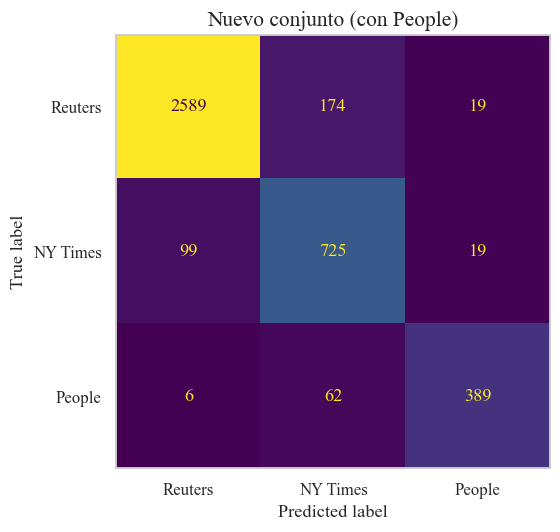

In [19]:
# Se reemplaza CNBC por People (entretenimiento), lo que aumenta el desbalance.
nuevos = ["Reuters", "The New York Times", "People"]
ORDER2 = ["Reuters", "NY Times", "People"]
L2 = {"Reuters": "Reuters", "NY Times": "The New York Times", "People": "People"}

d2 = df[df["publication"].isin(nuevos)].copy()
d2 = d2[d2["article"].notna()]
d2["CleanText"] = clean_text(d2, "article")
print(d2["publication"].value_counts())

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    d2["CleanText"], d2["publication"], test_size=0.30,
    stratify=d2["publication"], random_state=RANDOM_STATE)

nb2 = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", MultinomialNB(alpha=grid.best_params_["clf__alpha"])),
])
nb2.fit(X2_tr, y2_tr)
y2_pred = nb2.predict(X2_te)
print(f"\nAccuracy: {accuracy_score(y2_te, y2_pred):.4f}\n")
print(classification_report(y2_te, y2_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y2_te, y2_pred, labels=[L2[l] for l in ORDER2],
    display_labels=ORDER2, cmap="viridis", colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Nuevo conjunto (con People)"); plt.tight_layout(); plt.show()

## 6. Técnica alternativa de extracción de features
Busque información sobre al menos una técnica alternativa de extraer *features* de texto.
Explique brevemente cómo funciona y qué tipo de diferencias esperaría en los resultados.
No se espera que implemente nada en esta parte.

El análisis de una técnica alternativa de extracción de *features* (por ejemplo, *word embeddings*) se desarrolla en el informe.

## 7. Opcional: Clasificación a nivel de título
Repita la clasificación con los tres medios de prensa originales, pero esta vez clasificando a nivel de **título** en lugar de artículo completo.

In [20]:
# Clasificacion a nivel de titulo, con los mismos tres medios.
dt = df[df["publication"].isin(top_3_publications)].copy()
dt = dt[dt["title"].notna()]
dt["CleanTitle"] = clean_text(dt, "title")

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    dt["CleanTitle"], dt["publication"], test_size=0.30,
    stratify=dt["publication"], random_state=RANDOM_STATE)

nb_t = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", MultinomialNB(alpha=grid.best_params_["clf__alpha"])),
])
nb_t.fit(Xt_tr, yt_tr)
yt_pred = nb_t.predict(Xt_te)
print(f"Accuracy a nivel de titulo: {accuracy_score(yt_te, yt_pred):.4f}\n")
print(classification_report(yt_te, yt_pred))

Accuracy a nivel de titulo: 0.7149

                    precision    recall  f1-score   support

              CNBC       0.52      0.34      0.41       787
           Reuters       0.75      0.89      0.81      2830
The New York Times       0.67      0.49      0.56       852

          accuracy                           0.71      4469
         macro avg       0.65      0.57      0.60      4469
      weighted avg       0.70      0.71      0.70      4469

